# Block 2, Assignment 1: Adsorption Thermodynamics

**Group C**

**Team members:** Pamela Sampaa Afaki, Sarhini Nour, Chiara Nicole Bifulco, Alice Bolard

This notebook is our answer to Assignment 1, and it follows the order of the assignment sheet.

Part A is the classical thermodynamics part (60 points): the assumptions behind the Langmuir
model, its two limits, the temperature dependence of Henry's coefficient, the two-step procedure
for getting the parameters out of the isotherms, and the code for question 5.

Part B is the statistical thermodynamics part (40 points): the canonical ensemble and the four
relations we are asked to prove from its partition function.

We put the theory in markdown cells and the reasoning for each calculation just above the cell
that does it, the same way we did in the Block 1 project.

In [1]:
# Import needed modules
# numpy will be used to convert lists to arrays and to use log, exp and fitting functions
import numpy as np
# matplotlib will be used for plotting
import matplotlib.pyplot as plt

# Colour-blind-safe colours, one per temperature (same palette as our Block 1 project)
BLUE, RED, GREEN = "#0072B2", "#D55E00", "#009E73"

# Ideal gas constant in kJ/(mol.K), so that Delta H comes out directly in kJ/mol
R = 8.314e-3

---
# Part A. Classical Thermodynamics

The Langmuir isotherm links the gas uptake $q$ (mol kg$^{-1}$) to the pressure $P$ (Pa):

$$q(P) = \frac{q_{sat}\,k(T)\,P}{1 + k(T)\,P}$$

$q_{sat}$ is the saturation loading and $k$ (Pa$^{-1}$) is the equilibrium constant of the
adsorption step. Temperature only enters through $k$, through the Van 't Hoff equation:

$$k(T) = k_0 \exp\!\left(\frac{-\Delta H}{RT}\right)$$

Here $k_0$ (Pa$^{-1}$) is the standard equilibrium constant, $\Delta H$ (kJ mol$^{-1}$) is the
heat of adsorption and $R$ is the ideal gas constant in kJ mol$^{-1}$ K$^{-1}$.

## A.1 The three basic assumptions of the Langmuir model

1. The surface has a fixed number of adsorption sites and all of them are the same. Every site
   has the same heat of adsorption, so there are no strong and weak sites on the surface.

2. One molecule per site at most. A site is either empty or holds a single molecule, and
   molecules cannot pile up on top of each other. This is what limits the uptake to $q_{sat}$,
   which is reached when every site is full. The BET model we saw in the course drops this
   assumption and lets several layers form.

3. Adsorbed molecules do not interact with each other. Whether a site is occupied changes
   nothing for its neighbours, so the energy of adsorption does not depend on the coverage
   $\theta = q/q_{sat}$. The sites are therefore independent.

There is a fourth assumption that is not always written down: adsorption and desorption are in
dynamic equilibrium. $k(T)$ is the equilibrium constant of
gas + site $\rightleftharpoons$ adsorbed, and the isotherm describes the state where the two
rates balance.

## A.2 The two limiting regimes

### (a) High pressure ($P \to \infty$): the uptake reaches a plateau

We divide the top and the bottom of the Langmuir equation by $kP$, which we can do since $k>0$
and $P>0$:

$$q(P) = \frac{q_{sat}\,kP}{1+kP} = \frac{q_{sat}}{\dfrac{1}{kP} + 1}$$

When $P \to \infty$ the term $1/(kP)$ goes to zero, so

$$\lim_{P\to\infty} q(P) = \frac{q_{sat}}{0+1} = q_{sat}$$

The uptake stops at the finite value $q_{sat}$. We also wanted to check that this is really a
plateau and not just a finite limit, so we looked at the slope:

$$\frac{dq}{dP} = q_{sat}k\,\frac{(1+kP) - kP}{(1+kP)^{2}} = \frac{q_{sat}\,k}{(1+kP)^{2}}
\;\xrightarrow[P\to\infty]{}\; 0$$

The slope goes to zero like $1/P^{2}$, so the curve really does become flat. Physically, at high
pressure every site is occupied and the monolayer is complete. Raising the pressure further
cannot increase the loading, because assumption 2 does not allow a second layer.

### (b) Low pressure ($P \to 0$): the uptake is linear in pressure

Here $kP \ll 1$, so we can expand the denominator as a geometric series:

$$\frac{1}{1+kP} = 1 - kP + (kP)^{2} - \dots$$

which gives

$$q(P) = q_{sat}kP\left[1 - kP + (kP)^{2} - \dots\right]
= q_{sat}k\,P - q_{sat}k^{2}P^{2} + \mathcal{O}(P^{3})$$

Keeping only the first term,

$$q(P) \simeq q_{sat}\,k(T)\,P \qquad (P \to 0)$$

which is a straight line through the origin with slope $q_{sat}k$. We get the same answer from a
Taylor expansion of $q$ around $P=0$, since $q(0)=0$ and
$\left.\dfrac{dq}{dP}\right|_{P=0} = \dfrac{q_{sat}k}{(1+0)^2} = q_{sat}k$.

Physically, at low pressure the coverage $\theta = q/q_{sat}$ is very small, so almost every site
is free. A molecule arriving at the surface always finds somewhere to go, and the uptake just
follows the rate at which molecules hit the surface, which is proportional to $P$.

### Graphical check of the two limits

We plot the isotherm at 263 K together with the two limiting laws, to check that the curve really
follows $q = q_{sat}kP$ at low pressure and flattens onto $q = q_{sat}$ at high pressure.

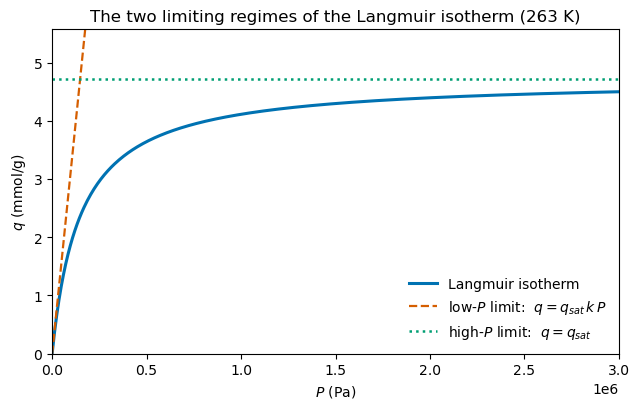

In [2]:
# Parameters of the 263 K isotherm (given further down by the researcher's fit)
qsat_demo = 4.72       # mmol/g
k_demo = 6.75e-06      # 1/Pa

P_demo = np.linspace(0, 3e6, 500)                                  # Pa
q_demo = qsat_demo * k_demo * P_demo / (1 + k_demo * P_demo)       # Langmuir
q_henry = qsat_demo * k_demo * P_demo                              # low-P limiting law

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(P_demo, q_demo, color=BLUE, lw=2.2, label="Langmuir isotherm")
ax.plot(P_demo, q_henry, color=RED, ls="--", lw=1.6,
        label=r"low-$P$ limit:  $q = q_{sat}\,k\,P$")
ax.axhline(qsat_demo, color=GREEN, ls=":", lw=1.8,
           label=r"high-$P$ limit:  $q = q_{sat}$")

ax.set_xlim(0, 3e6)
ax.set_ylim(0, 1.18 * qsat_demo)
ax.set_xlabel("$P$ (Pa)")
ax.set_ylabel("$q$ (mmol/g)")
ax.set_title("The two limiting regimes of the Langmuir isotherm (263 K)")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

The plot behaves the way we expected. The isotherm is tangent to the red line at the origin and
approaches the green plateau at high pressure.

## A.3 Temperature dependence of Henry's coefficient

Henry's coefficient is the initial slope of the isotherm, so it is the constant in front of $P$
in the limit we found in A.2(b):

$$K_H \equiv \lim_{P\to 0}\frac{q}{P} = \lim_{P\to 0}\frac{q_{sat}\,k}{1+kP} = q_{sat}\,k(T)$$

$q_{sat}$ counts the sites of the material, so it does not depend on temperature. That means the
whole temperature dependence of $K_H$ sits in $k(T)$. Putting in the Van 't Hoff equation:

$$K_H(T) = q_{sat}\,k_0\,\exp\!\left(\frac{-\Delta H}{RT}\right)
= K_H^{0}\exp\!\left(\frac{-\Delta H}{RT}\right), \qquad K_H^{0} = q_{sat}k_0 $$

Taking the logarithm gives something linear in $1/T$:

$$\ln K_H = \ln\!\left(q_{sat}k_0\right) - \frac{\Delta H}{R}\cdot\frac{1}{T}$$

So $K_H$ follows the same Arrhenius-type law as $k$, with the same slope $-\Delta H/R$. The only
difference between the two is the constant $\ln q_{sat}$ added to the intercept.

For the sign, adsorption is exothermic, so $\Delta H < 0$ and $-\Delta H/(RT) = |\Delta H|/(RT)$
is positive. When $T$ goes up, $|\Delta H|/(RT)$ gets smaller and $K_H$ goes down, so the
material holds the gas less strongly when it is hot. This is what makes temperature swing
adsorption work: the CO$_2$ is captured cold and released by heating the adsorbent.

## A.4 How to extract $q_{sat}$, $k_0$ and $\Delta H$ from the isotherms

The researcher has three CO$_2$ isotherms on her MOF, at 263, 303 and 343 K, and she wants
$q_{sat}$, $k_0$ and $\Delta H$. This is done in two steps.

### Step 1: fit each isotherm to the Langmuir model to get $q_{sat}$ and one $k$ per temperature

The Langmuir equation is not linear in its parameters, so we cannot fit it directly with a
straight line. We can linearise it by taking the reciprocal of both sides:

$$\frac{1}{q} = \frac{1+kP}{q_{sat}kP} = \frac{1}{q_{sat}k}\cdot\frac{1}{P} + \frac{1}{q_{sat}}$$

This has the form $y = m\,x + b$ with

$$y = \frac{1}{q}, \qquad x = \frac{1}{P}, \qquad
m = \frac{1}{q_{sat}k}, \qquad b = \frac{1}{q_{sat}}$$

So if we plot $1/q$ against $1/P$ we get a straight line, and the two parameters come out of the
intercept and the slope:

$$q_{sat} = \frac{1}{b}, \qquad\qquad k = \frac{b}{m}$$

There is a second linearisation, $P/q = P/q_{sat} + 1/(q_{sat}k)$, where the slope gives
$1/q_{sat}$ and the intercept gives $1/(q_{sat}k)$. We looked at both and kept the reciprocal
form, because there the intercept is directly $1/q_{sat}$, which is the parameter the assignment
tells us to compute only once.

Using the fact that $q_{sat}$ does not depend on temperature. $q_{sat}$ counts the sites in the
framework, which is a structural property, so it is the same at all three temperatures. The
assignment asks us to compute it once at 263 K, and that is also the sensible choice
numerically. The 263 K isotherm is the one that gets closest to saturation, so its plateau, and
with it the intercept $b = 1/q_{sat}$, is the best defined of the three. So we do this:

at 263 K, the full fit with two parameters, which gives $q_{sat}$ and $k(263)$;

at 303 K and 343 K, keep $q_{sat}$ fixed at the 263 K value and fit only $k(T)$. On the
linearised plot this means forcing the intercept to $1/q_{sat}$, so we fit the one-parameter line
$\;\dfrac{1}{q} - \dfrac{1}{q_{sat}} = \dfrac{1}{q_{sat}k}\cdot\dfrac{1}{P}\;$ through the
origin, and then $k(T) = 1/(q_{sat}\,m)$.

Doing it this way is not only physically right, it also helps the fit. The two hot isotherms are
far from saturation, so if we let $q_{sat}$ go free there it would be badly determined and the
error would leak into $k$.

What the graphs look like. On the $q$ against $P$ plot the three isotherms all head for the same
plateau $q_{sat}$. The hotter the isotherm, the more slowly it climbs, because $k$ and the
initial slope $q_{sat}k$ are smaller. On the linearised plot the three lines share the same
intercept $1/q_{sat}$ and their slopes $1/(q_{sat}k)$ grow with temperature. We plot both below.

We were not given the raw isotherms, only the results of the fit, so to show the procedure we
generated our own data. We used the known parameters to build three isotherms, added 2 % random
noise so that they look like real computational data, and then ran the two-step fit on them. If
our method is right it has to give back the parameters we started from.

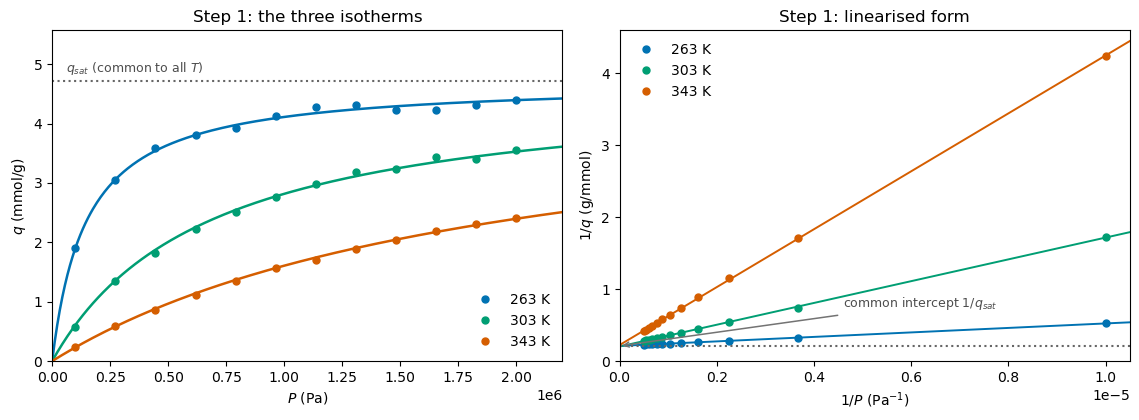

In [3]:
# --- Synthetic isotherm data, used only to illustrate the Step 1 fitting procedure ---
qsat_true = 4.72                                             # mmol/g
k_true = {263: 6.75e-06, 303: 1.48e-06, 343: 5.16e-07}       # 1/Pa

rng = np.random.default_rng(0)                               # fixed seed -> reproducible
P_data = np.linspace(1.0e5, 2.0e6, 12)                       # Pa, 12 pressure points

q_data = {}
for T_i, k_i in k_true.items():
    q_ideal = qsat_true * k_i * P_data / (1 + k_i * P_data)
    q_data[T_i] = q_ideal * (1 + 0.02 * rng.standard_normal(P_data.size))   # 2% noise

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.3))

# ---- Left: the three isotherms, q vs P ----
for T_i, colour in zip([263, 303, 343], [BLUE, GREEN, RED]):
    P_fine = np.linspace(0, 2.2e6, 400)
    q_fine = qsat_true * k_true[T_i] * P_fine / (1 + k_true[T_i] * P_fine)
    ax1.plot(P_fine, q_fine, color=colour, lw=1.8)
    ax1.plot(P_data, q_data[T_i], "o", color=colour, ms=5, label=f"{T_i} K")

ax1.axhline(qsat_true, color="0.4", ls=":", lw=1.5)
ax1.text(6e4, qsat_true * 1.03, r"$q_{sat}$ (common to all $T$)", color="0.3", fontsize=9)
ax1.set_xlabel("$P$ (Pa)")
ax1.set_ylabel("$q$ (mmol/g)")
ax1.set_title("Step 1: the three isotherms")
ax1.set_xlim(0, 2.2e6)
ax1.set_ylim(0, 1.18 * qsat_true)
ax1.legend(frameon=False, loc="lower right")

# ---- Right: the linearised form, 1/q vs 1/P ----
x_line = np.linspace(0, 1.05e-5, 50)      # common range, extended back to the intercept
for T_i, colour in zip([263, 303, 343], [BLUE, GREEN, RED]):
    ax2.plot(1 / P_data, 1 / q_data[T_i], "o", color=colour, ms=5, label=f"{T_i} K")
    m_i, b_i = np.polyfit(1 / P_data, 1 / q_data[T_i], 1)
    ax2.plot(x_line, m_i * x_line + b_i, color=colour, lw=1.4)

ax2.axhline(1 / qsat_true, color="0.4", ls=":", lw=1.5)
ax2.annotate(r"common intercept $1/q_{sat}$", xy=(0, 1 / qsat_true),
             xytext=(4.6e-6, 0.75), color="0.3", fontsize=9,
             arrowprops=dict(arrowstyle="->", color="0.45", lw=1.1))

ax2.set_xlim(0, 1.05e-5)
ax2.set_ylim(0, 4.6)
ax2.set_xlabel(r"$1/P$ (Pa$^{-1}$)")
ax2.set_ylabel(r"$1/q$ (g/mmol)")
ax2.set_title("Step 1: linearised form")
ax2.legend(frameon=False, loc="upper left")

fig.tight_layout()
plt.show()

In [4]:
# --- Step 1 carried out numerically ---

x = 1 / P_data     # the abscissa of the linearised plot is the same at every temperature

# (a) 263 K: full two-parameter fit -> both qsat and k(263)
slope_263, intercept_263 = np.polyfit(x, 1 / q_data[263], 1)
qsat_fitted = 1 / intercept_263
k_fitted = {263: intercept_263 / slope_263}

# (b) 303 K and 343 K: qsat is FIXED to the 263 K value, only k is fitted.
#     The line is forced through the origin after subtracting the known intercept,
#     so the least-squares slope is simply sum(x*y)/sum(x*x).
for T_i in (303, 343):
    y_shifted = 1 / q_data[T_i] - 1 / qsat_fitted
    slope_i = np.sum(x * y_shifted) / np.sum(x * x)
    k_fitted[T_i] = 1 / (qsat_fitted * slope_i)

print(f"qsat recovered from the 263 K isotherm : {qsat_fitted:.3f} mmol/g "
      f"(input value {qsat_true:.2f})\n")
print(f"{'T (K)':>7} | {'k fitted (1/Pa)':>17} | {'k input (1/Pa)':>16} | {'rel. error':>10}")
print("-" * 62)
for T_i in (263, 303, 343):
    err = abs(k_fitted[T_i] - k_true[T_i]) / k_true[T_i]
    print(f"{T_i:>7} | {k_fitted[T_i]:>17.3e} | {k_true[T_i]:>16.3e} | {err:>9.1%}")

qsat recovered from the 263 K isotherm : 4.716 mmol/g (input value 4.72)

  T (K) |   k fitted (1/Pa) |   k input (1/Pa) | rel. error
--------------------------------------------------------------
    263 |         6.796e-06 |        6.750e-06 |      0.7%
    303 |         1.415e-06 |        1.480e-06 |      4.4%
    343 |         5.236e-07 |        5.160e-07 |      1.5%


The fit gives back the input parameters to within a few percent, and what is left over is just
the noise we added. This tells us that the linearisation and the way we fixed $q_{sat}$ at 263 K
are implemented correctly.

We were surprised at first that the error is not smallest at 263 K, where we did the full fit.
We then re-ran the cell with different random seeds and found that which temperature comes out
worst changes from one seed to the next, so it is the noise and not the method.

### Step 2: use the Van 't Hoff equation to get $k_0$ and $\Delta H$

Step 1 gave us three values $k(263)$, $k(303)$ and $k(343)$, one per temperature. They are linked
by the Van 't Hoff equation

$$k(T) = k_0 \exp\!\left(\frac{-\Delta H}{RT}\right)$$

which still has the two unknowns $k_0$ and $\Delta H$ in it. Taking the natural logarithm makes
it linear:

$$\ln k = \ln k_0 - \frac{\Delta H}{R}\cdot\frac{1}{T}$$

This is again of the form $y = m\,x + b$, now with

$$y = \ln k, \qquad x = \frac{1}{T}, \qquad
m = -\frac{\Delta H}{R}, \qquad b = \ln k_0$$

So we plot $\ln k$ against $1/T$, fit a straight line through the three points, and read off

$$\Delta H = -R\,m, \qquad\qquad k_0 = e^{\,b}$$

Adsorption is exothermic, so we expect $\Delta H < 0$ and therefore a positive slope
$m = -\Delta H/R$. Step 1 already found the largest $k$ at 263 K and the smallest at 343 K, so
the slope has to come out positive. We used this as a check on the code.

This second step is what question 5 asks us to write.

---
## A.5 Code

#### After the researcher did the fitting, she obtained the following values:

    qsat = 4.72 mmol/g
    k(263) = 6.75e-06 1/Pa
    k(303) = 1.48e-06 1/Pa
    k(343) = 5.16e-07 1/Pa

#### (a) Use the Van 't Hoff equation to obtain k0 and delta H

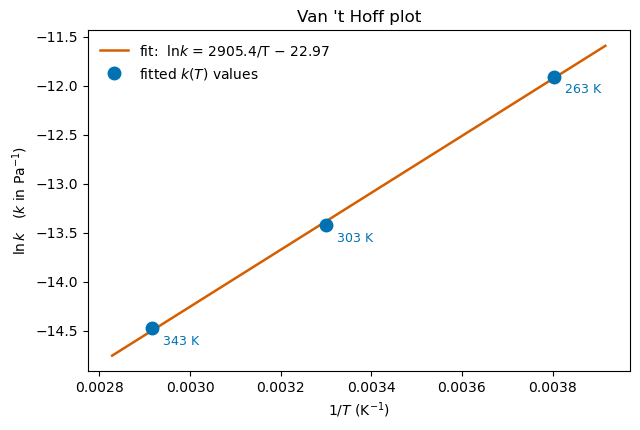

slope      =    2905.44 K        (= -dH/R)
intercept  =   -22.9712           (= ln k0)
R^2        =   0.999233

Delta H    =     -24.16 kJ/mol
k0         =  1.056e-10 1/Pa


In [5]:
# Group the temperatures and K values in arrays
T = np.array([263.0, 303.0, 343.0])                 # K
k = np.array([6.75e-06, 1.48e-06, 5.16e-07])        # 1/Pa
qsat = 4.72                                         # mmol/g  (temperature independent)

# We know that we need to plot lnk vs. 1/T
# because  ln k = ln k0 - (dH/R) * (1/T)  is linear in 1/T
inv_T = 1.0 / T
ln_k = np.log(k)

# Solve for the unknowns by linear fitting
# np.polyfit with degree 1 returns [slope, intercept] of the least-squares line
slope, intercept = np.polyfit(inv_T, ln_k, 1)

# slope = -dH/R  ->  dH = -R * slope        (kJ/mol, since R is in kJ/(mol.K))
# intercept = ln k0  ->  k0 = exp(intercept)  (1/Pa)
delta_H = -R * slope
k0 = np.exp(intercept)

# Coefficient of determination, to check how well the three points sit on a line
residuals = ln_k - (slope * inv_T + intercept)
r_squared = 1 - np.sum(residuals**2) / np.sum((ln_k - ln_k.mean())**2)

# Plot of lnk vs. 1/T
fig, ax = plt.subplots(figsize=(6.5, 4.4))
x_line = np.linspace(inv_T.min() * 0.97, inv_T.max() * 1.03, 100)
ax.plot(x_line, slope * x_line + intercept, color=RED, lw=1.8,
        label=f"fit:  ln$k$ = {slope:.1f}/T $-$ {abs(intercept):.2f}")
ax.plot(inv_T, ln_k, "o", color=BLUE, ms=9, label="fitted $k(T)$ values")

for x_i, y_i, T_i in zip(inv_T, ln_k, T):
    ax.annotate(f"{T_i:.0f} K", (x_i, y_i), textcoords="offset points",
                xytext=(8, -12), fontsize=9, color=BLUE)

ax.set_xlabel(r"$1/T$ (K$^{-1}$)")
ax.set_ylabel(r"$\ln k$   ($k$ in Pa$^{-1}$)")
ax.set_title("Van 't Hoff plot")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

# Print the results
print(f"slope      = {slope:10.2f} K        (= -dH/R)")
print(f"intercept  = {intercept:10.4f}           (= ln k0)")
print(f"R^2        = {r_squared:10.6f}\n")
print(f"Delta H    = {delta_H:10.2f} kJ/mol")
print(f"k0         = {k0:10.3e} 1/Pa")

**Result of (a).**

$$\Delta H \approx -24.2\ \mathrm{kJ\,mol^{-1}}, \qquad k_0 \approx 1.06\times 10^{-10}\ \mathrm{Pa^{-1}}$$

The three points sit on a straight line with $R^2 \approx 0.9992$, so the Van 't Hoff equation
describes this data well over the range we have. We then checked whether the two numbers make
sense.

$\Delta H$ comes out negative, which it has to, since adsorption releases heat. Its size, about
24 kJ mol$^{-1}$, or 0.25 eV per molecule, is in the range we saw in the course for
physisorption of CO$_2$ in MOFs (20-35 kJ mol$^{-1}$). It is much smaller than the several eV we
would expect for chemisorption, so the CO$_2$ is held by van der Waals and electrostatic
interactions and is not bound to the framework.

$k_0$ is very small, around $10^{-10}$ Pa$^{-1}$, and at first we thought we had made a mistake.
It is not a mistake. $k_0$ is only the prefactor of the exponential, so it is the value $k$ would
have at infinite temperature, where the energy gained by adsorbing no longer counts against
thermal agitation. We get the real $k(T)$ back by multiplying it by $\exp(|\Delta H|/RT)$, which
is about $6.3\times 10^{4}$ at 263 K.

#### (b) Calculate Henry's coefficients for the different temperatures

In [6]:
# Calculating the Henry's coefficients

# Remember the formula for Kh (mmol/(g.Pa))
#   Kh = lim_{P->0} q/P = qsat * k(T)
K_H = qsat * k

# Cross-check: rebuild k(T) from the two parameters we just fitted, Kh = qsat*k0*exp(-dH/RT)
K_H_model = qsat * k0 * np.exp(-delta_H / (R * T))

# print the results
print(f"{'T (K)':>7} | {'k (1/Pa)':>12} | {'K_H (mmol/(g.Pa))':>19} | {'K_H from fit':>14}")
print("-" * 62)
for T_i, k_i, KH_i, KHm_i in zip(T, k, K_H, K_H_model):
    print(f"{T_i:>7.0f} | {k_i:>12.3e} | {KH_i:>19.3e} | {KHm_i:>14.3e}")

print(f"\nK_H(263 K) / K_H(343 K) = {K_H[0] / K_H[-1]:.1f}")

  T (K) |     k (1/Pa) |   K_H (mmol/(g.Pa)) |   K_H from fit
--------------------------------------------------------------
    263 |    6.750e-06 |           3.186e-05 |      3.130e-05
    303 |    1.480e-06 |           6.986e-06 |      7.280e-06
    343 |    5.160e-07 |           2.436e-06 |      2.379e-06

K_H(263 K) / K_H(343 K) = 13.1


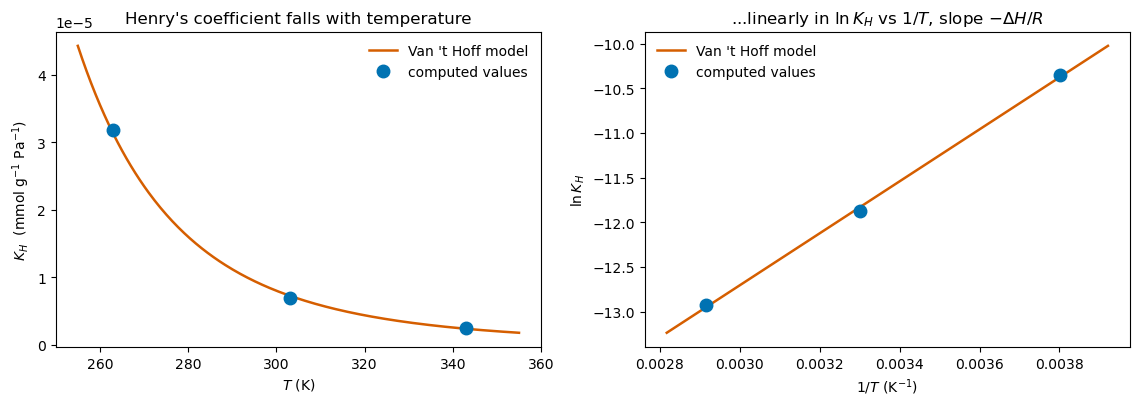

In [7]:
# The same exponential decrease, shown graphically
fig, (axa, axb) = plt.subplots(1, 2, figsize=(11.5, 4.3))

T_fine = np.linspace(255, 355, 300)
K_H_fine = qsat * k0 * np.exp(-delta_H / (R * T_fine))

axa.plot(T_fine, K_H_fine, color=RED, lw=1.8, label="Van 't Hoff model")
axa.plot(T, K_H, "o", color=BLUE, ms=9, label="computed values")
axa.set_xlabel("$T$ (K)")
axa.set_ylabel(r"$K_H$  (mmol g$^{-1}$ Pa$^{-1}$)")
axa.set_title("Henry's coefficient falls with temperature")
axa.legend(frameon=False)

axb.plot(1 / T_fine, np.log(K_H_fine), color=RED, lw=1.8, label="Van 't Hoff model")
axb.plot(1 / T, np.log(K_H), "o", color=BLUE, ms=9, label="computed values")
axb.set_xlabel(r"$1/T$ (K$^{-1}$)")
axb.set_ylabel(r"$\ln K_H$")
axb.set_title(r"...linearly in $\ln K_H$ vs $1/T$, slope $-\Delta H/R$")
axb.legend(frameon=False, loc="upper left")

fig.tight_layout()
plt.show()

### Discussion of the trend

| $T$ (K) | $k$ (Pa$^{-1}$) | $K_H = q_{sat}k$ (mmol g$^{-1}$ Pa$^{-1}$) |
|:---:|:---:|:---:|
| 263 | $6.75\times10^{-6}$ | $3.19\times10^{-5}$ |
| 303 | $1.48\times10^{-6}$ | $6.99\times10^{-6}$ |
| 343 | $5.16\times10^{-7}$ | $2.44\times10^{-6}$ |

Henry's coefficient goes down as the temperature goes up, by about a factor of 13 between 263 K
and 343 K. We can explain this in three ways.

From the formula. In A.3 we found $K_H = q_{sat}k_0\exp(-\Delta H/RT)$ with $\Delta H<0$, so the
exponent $|\Delta H|/(RT)$ shrinks as $T$ grows and $K_H$ falls with it. The fall is exponential
and not linear, which is why only 80 K of heating costs more than a factor of ten. $q_{sat}$
plays no part in the trend, since it does not depend on temperature and only sets the overall
scale, so $k$ and $K_H$ drop in exactly the same proportion.

From thermodynamics. Adsorption is exothermic, $\Delta H \approx -24$ kJ mol$^{-1}$, so heating
the system pushes the equilibrium gas + site $\rightleftharpoons$ adsorbed back towards the gas,
by Le Chatelier. The equilibrium constant falls and so does the initial slope of the isotherm.

From statistical thermodynamics, which links this to Part B. $K_H$ measures the balance between
the energy a molecule gains from interacting with the pore walls and the entropy it loses by
being confined in the pore. The energy gain comes in through a Boltzmann factor $\exp(-U/k_BT)$,
so its weight is destroyed once $k_BT$ becomes comparable to $|U|$, while the entropy cost of
confinement barely changes with temperature. At high temperature the entropy term wins and the
molecule stays in the gas.

Why this matters in practice. This is the basis of temperature swing adsorption, the process from
the course notes. The CO$_2$ is captured from the flue gas at low temperature where $K_H$ is
large, and the adsorbent is regenerated by heating, where $K_H$ is small and the CO$_2$ comes
back off. The working capacity is the difference in loading between the two temperatures, so a
large $|\Delta H|$ gives a bigger temperature contrast and a bigger working capacity. It also
makes regeneration cost more energy, so a good capture material has to balance the two.

---
# Part B. Statistical Thermodynamics

The heat of adsorption at zero loading that we fitted in Part A can also be calculated from the
microscopic side, in the canonical $(N,V,T)$ ensemble. This part sets up that ensemble and
derives its thermodynamics.

We write $\beta = \dfrac{1}{k_B T}$ throughout, with $k_B$ the Boltzmann constant.

## B.1 The canonical ensemble in the context of adsorption

The canonical ensemble is the set of all microstates a system can be in when its number of
particles $N$ and its volume $V$ are fixed. The system is also in thermal contact with a large
reservoir, which fixes its temperature $T$. The energy is not fixed. The system exchanges heat with
the reservoir, so its energy fluctuates and only the average $\langle E\rangle$ is well defined.
That average is what we call the internal energy. The microstates are not equally probable, the
way they would be in the microcanonical ensemble. They carry a Boltzmann weight, because the
number of reservoir microstates that go with a given system energy falls off exponentially with
that energy.

For adsorption, the system is a fixed number $N$ of adsorbate molecules, here CO$_2$, inside the
pore volume $V$ of the adsorbent, at the temperature of the surroundings.

$V$ is a real constraint, because we assume the MOF framework does not deform over the pressure
range of the isotherm. As the course notes point out, we cannot change the volume of the solid,
so the pressure is not defined inside the adsorbent. That is why $(N,V,T)$ and not $(N,P,T)$ is
the natural ensemble here.

$N$ is fixed, so the loading is imposed. This is the difference from the grand canonical
$(\mu,V,T)$ ensemble, where the adsorbed phase can exchange molecules with a gas reservoir, and
which is what is actually used to simulate a whole isotherm.

Having $N$ fixed is what makes NVT the right ensemble for the heat of adsorption at zero loading.
We take the limit of one single probe molecule, $N = 1$, dropped at random positions in the empty
framework, and average its interaction energy with the walls. The difference between that average
and the energy of the same molecule in the gas phase is the differential heat of adsorption at
zero coverage. The same average also gives Henry's coefficient,
$K_H = \frac{1}{k_BT}\left\langle \exp\!\left(-\frac{U_{\mathrm{CO_2}}}{k_BT}\right)\right\rangle$,
which is the quantity we computed numerically in A.5(b).

## B.2 The partition function of the canonical ensemble

We sum the Boltzmann weight over every microstate $\nu$ the system can reach at fixed $N$ and
$V$. That sum is the canonical partition function:

$$\mathrm{Q}(N,V,T) = \sum_{\nu} e^{-E_\nu / k_B T} = \sum_{\nu} e^{-\beta E_\nu}$$

where $E_\nu$ is the energy of microstate $\nu$. The sum runs over microstates and not over
energy levels. If we would rather sum over the distinct levels, we have to weight each one by its
degeneracy $g(E)$, so $\;\mathrm{Q} = \sum_E g(E)\,e^{-\beta E}$.

$\mathrm{Q}$ depends on $N$, $V$ and $T$ only. The energies $E_\nu$ come from the Hamiltonian,
which depends on $N$ and $V$ but not on $T$. We use this several times in B.4.

For a classical system of $N$ identical particles the sum becomes an integral over phase space,
normalised by Planck's constant and by $N!$ because the particles are indistinguishable:

$$\mathrm{Q}(N,V,T) = \frac{1}{\Lambda^{3N} N!}\int e^{-\beta\,U(\mathbf{r}^N)}\,d\mathbf{r}^{3N},
\qquad \Lambda = \sqrt{\frac{h^{2}}{2\pi m k_B T}}$$

with $\Lambda$ the thermal de Broglie wavelength.

## B.3 Probability of a microstate

The probability of finding the system in a given microstate $\nu$ of energy $E_\nu$ is the
Boltzmann weight of that microstate divided by the partition function:

$$P_\nu = \frac{e^{-E_\nu/k_BT}}{\mathrm{Q}} = \frac{e^{-\beta E_\nu}}{\mathrm{Q}}$$

The normalisation works out on its own, and it is really what defines $\mathrm{Q}$:

$$\sum_\nu P_\nu = \frac{1}{\mathrm{Q}}\sum_\nu e^{-\beta E_\nu} = \frac{\mathrm{Q}}{\mathrm{Q}} = 1$$

We need the logarithm of this in the entropy proof, so we write it down here:

$$\ln P_\nu = -\beta E_\nu - \ln \mathrm{Q} \tag{$\star$}$$

## B.4 Derivation of the thermodynamic quantities

We prove the four relations in an order where each one gets used by the next. We start with $E$,
then $\langle S\rangle$, then the free energy that comes out of those two, and finally $P$ and
$\mu$. Taking them in the order given on the sheet also works, but then the free energy has to be
brought in twice.

---

### (i) $\;E = k_B T^{2}\left(\dfrac{\partial \ln \mathrm{Q}}{\partial T}\right)_{V,N}$

The internal energy is the average of the microstate energies:

$$E = \langle E\rangle = \sum_\nu P_\nu E_\nu = \frac{1}{\mathrm{Q}}\sum_\nu E_\nu e^{-\beta E_\nu}$$

Now we differentiate $\mathrm{Q}$ with respect to $T$ at fixed $V$ and $N$. The energies $E_\nu$
do not depend on $T$, since they are set by the Hamiltonian and so by $V$ and $N$, so only the
exponentials get differentiated:

$$\left(\frac{\partial \mathrm{Q}}{\partial T}\right)_{V,N}
= \sum_\nu \frac{\partial}{\partial T}e^{-E_\nu/k_BT}
= \sum_\nu \frac{E_\nu}{k_B T^{2}}\,e^{-E_\nu/k_BT}
= \frac{1}{k_BT^{2}}\sum_\nu E_\nu e^{-\beta E_\nu}$$

We divide both sides by $\mathrm{Q}$ and recognise the average:

$$\left(\frac{\partial \ln \mathrm{Q}}{\partial T}\right)_{V,N}
= \frac{1}{\mathrm{Q}}\left(\frac{\partial \mathrm{Q}}{\partial T}\right)_{V,N}
= \frac{1}{k_BT^{2}}\sum_\nu E_\nu \underbrace{\frac{e^{-\beta E_\nu}}{\mathrm{Q}}}_{P_\nu}
= \frac{\langle E\rangle}{k_BT^{2}}$$

and rearranging gives

$$E = k_B T^{2}\left(\frac{\partial \ln \mathrm{Q}}{\partial T}\right)_{V,N}
\qquad\blacksquare$$

### (ii) $\;\langle S\rangle = k_B\ln \mathrm{Q} + k_B T\left(\dfrac{\partial \ln \mathrm{Q}}{\partial T}\right)_{N,V}$

As the hint says, we start from the statistical definition of the entropy,

$$\langle S\rangle = -k_B \sum_\nu P_\nu \ln P_\nu$$

and put in $(\star)$, $\ln P_\nu = -\beta E_\nu - \ln \mathrm{Q}$:

$$\langle S\rangle
= -k_B\sum_\nu P_\nu\left(-\beta E_\nu - \ln \mathrm{Q}\right)
= k_B\beta\sum_\nu P_\nu E_\nu + k_B \ln \mathrm{Q}\sum_\nu P_\nu$$

The first sum is $\langle E\rangle$. The second is the normalisation $\sum_\nu P_\nu = 1$, and
$\ln\mathrm{Q}$ could come out of the sum because it is a constant. Using $k_B\beta = 1/T$:

$$\langle S\rangle = \frac{\langle E\rangle}{T} + k_B\ln \mathrm{Q} \tag{$\dagger$}$$

Now we put in the result of (i),
$\langle E\rangle = k_BT^{2}\left(\partial\ln\mathrm{Q}/\partial T\right)_{V,N}$:

$$\langle S\rangle
= \frac{1}{T}\,k_BT^{2}\left(\frac{\partial \ln \mathrm{Q}}{\partial T}\right)_{N,V} + k_B\ln \mathrm{Q}$$

$$\langle S\rangle = k_B\ln \mathrm{Q} + k_B T\left(\frac{\partial \ln \mathrm{Q}}{\partial T}\right)_{N,V}
\qquad\blacksquare$$

### Intermediate result: the bridge to the Helmholtz free energy

The last two proofs are much shorter if we first find the thermodynamic potential of the
canonical ensemble. Rearranging $(\dagger)$:

$$T\langle S\rangle = \langle E\rangle + k_BT\ln\mathrm{Q}
\qquad\Longrightarrow\qquad
\langle E\rangle - T\langle S\rangle = -k_B T \ln \mathrm{Q}$$

and $E - TS$ is by definition the Helmholtz free energy $F$, so

$$F(N,V,T) = -k_B T \ln \mathrm{Q}$$

This is the bridge relation of the canonical ensemble. We get its differential from the first law
together with $dE = TdS - PdV + \mu\,dN$:

$$dF = dE - T\,dS - S\,dT = \left(T dS - P dV + \mu dN\right) - T dS - S dT$$

$$dF = -S\,dT - P\,dV + \mu\,dN$$

and from there we read off

$$P = -\left(\frac{\partial F}{\partial V}\right)_{T,N},
\qquad
\mu = +\left(\frac{\partial F}{\partial N}\right)_{T,V}$$

These two give the remaining proofs in one line each.

### (iii) $\;P = k_B T\left(\dfrac{\partial \ln \mathrm{Q}}{\partial V}\right)_{N,T}$

Putting $F = -k_BT\ln\mathrm{Q}$ into $P = -\left(\partial F/\partial V\right)_{T,N}$:

$$P = -\left(\frac{\partial}{\partial V}\Big[-k_BT\ln\mathrm{Q}\Big]\right)_{T,N}$$

$$P = k_B T\left(\frac{\partial \ln \mathrm{Q}}{\partial V}\right)_{N,T}
\qquad\blacksquare$$

We also did this one directly, without going through $F$, because we wanted to see where the
pressure comes from microscopically. Differentiating $E = \sum_\nu P_\nu E_\nu$ gives two terms:

$$dE = \underbrace{\sum_\nu E_\nu\,dP_\nu}_{\text{the occupations change}}
+ \underbrace{\sum_\nu P_\nu\,dE_\nu}_{\text{the levels themselves move}}$$

At fixed $T$ and $N$ the second term is the mechanical work $-P\,dV$, and the $E_\nu$ depend on
$V$, so

$$-P\,dV = \sum_\nu P_\nu \left(\frac{\partial E_\nu}{\partial V}\right)dV
\qquad\Longrightarrow\qquad
P = -\sum_\nu P_\nu \frac{\partial E_\nu}{\partial V}$$

On the other side, differentiating $\ln\mathrm{Q}$ with respect to $V$:

$$\left(\frac{\partial \ln \mathrm{Q}}{\partial V}\right)_{N,T}
= \frac{1}{\mathrm{Q}}\sum_\nu \left(-\beta\frac{\partial E_\nu}{\partial V}\right)e^{-\beta E_\nu}
= -\beta\sum_\nu P_\nu\frac{\partial E_\nu}{\partial V}
= \beta\,P$$

so $P = k_BT\left(\partial\ln\mathrm{Q}/\partial V\right)_{N,T}$, the same answer. This second
route was worth doing, because it shows what heat and work are microscopically. Heat changes how
the microstates are populated, and work changes the energies of the microstates themselves.

### (iv) $\;\mu = -k_B T\left(\dfrac{\partial \ln \mathrm{Q}}{\partial N}\right)_{V,T}$

Putting $F = -k_BT\ln\mathrm{Q}$ into $\mu = \left(\partial F/\partial N\right)_{T,V}$:

$$\mu = \left(\frac{\partial}{\partial N}\Big[-k_BT\ln\mathrm{Q}\Big]\right)_{V,T}$$

$$\mu = -k_B T\left(\frac{\partial \ln \mathrm{Q}}{\partial N}\right)_{V,T}
\qquad\blacksquare$$

One thing we noticed here. $N$ is an integer, so strictly this derivative is a finite difference,

$$\mu = F(N+1,V,T) - F(N,V,T) = -k_BT\ln\frac{\mathrm{Q}_{N+1}}{\mathrm{Q}_N}$$

which only becomes the derivative above in the thermodynamic limit $N \gg 1$. Written this way it
is the Widom test particle formula from the course, since $\mathrm{Q}_{N+1}/\mathrm{Q}_N$ is the
average Boltzmann factor for inserting one extra molecule. So $\mu$ is obtained by trying random
insertions and averaging $e^{-\beta\Delta U^{+}}$, which is how the excess chemical potential,
and with it $K_H$, is computed in a simulation.

### How Part B connects back to Part A

Putting the four relations together brings the assignment back to where it started. The
equilibrium condition between the gas and the adsorbed phase is equal temperature and equal
chemical potential, $\mu^{\mathrm{gas}}(T,P) = \mu^{\mathrm{ads}}(T,\sigma)$. Relation (iv) tells
us how to get $\mu^{\mathrm{ads}}$ from a partition function. If we write $\mu^{\mathrm{ads}}$ as
an ideal gas part plus an excess part $\mu^{\mathrm{ex}}$ and impose the equality, we get

$$\sigma = \frac{P}{k_BT}\exp\!\left(-\frac{\mu^{\mathrm{ex}}(T,\sigma)}{k_BT}\right)
\;\xrightarrow[\;P\to 0\;]{}\;
\sigma = K_H\,P,
\qquad K_H = \frac{1}{k_BT}\exp\!\left(-\frac{\mu^{\mathrm{ex}}(T,0)}{k_BT}\right)$$

This is the same linear low pressure regime we proved in A.2(b). The difference is that we got it
here from the microscopic side, not from the Langmuir equation. Relation (i) gives the average energy,
and the difference between that energy in the adsorbed phase and in the gas phase is the heat of
adsorption, the $\Delta H \approx -24$ kJ mol$^{-1}$ we fitted in A.5(a). So the Langmuir
parameters in Part A and the ensemble averages in Part B are two ways of describing the same
thing.

---
# Summary of results

| Quantity | Value | Where |
|:---|:---|:---|
| $q_{sat}$ | 4.72 mmol g$^{-1}$ (given, does not depend on $T$) | A.4 |
| $\Delta H$ | $-24.16$ kJ mol$^{-1}$ | A.5(a) |
| $k_0$ | $1.06\times10^{-10}$ Pa$^{-1}$ | A.5(a) |
| $K_H(263\ \mathrm{K})$ | $3.19\times10^{-5}$ mmol g$^{-1}$ Pa$^{-1}$ | A.5(b) |
| $K_H(303\ \mathrm{K})$ | $6.99\times10^{-6}$ mmol g$^{-1}$ Pa$^{-1}$ | A.5(b) |
| $K_H(343\ \mathrm{K})$ | $2.44\times10^{-6}$ mmol g$^{-1}$ Pa$^{-1}$ | A.5(b) |

What we learned from this assignment:

Both limits of the Langmuir model come from the same assumption, that there is a finite number of
independent sites holding one molecule each. Saturation at high pressure and linearity at low
pressure are not two separate results.

Linearising a model is what lets us fit it with a simple least squares line, and which
linearisation we pick matters. Plotting $1/q$ against $1/P$ puts $q_{sat}$ in the intercept, and
plotting $\ln k$ against $1/T$ puts $\Delta H$ in the slope. Each time we chose the plot that
isolates the unknown we were after.

Knowing that $q_{sat}$ does not depend on temperature is worth more than it looks. It takes one
free parameter out of two of the three fits, exactly where the data could not have pinned it
down anyway.

The $\Delta H \approx -24$ kJ mol$^{-1}$ we fitted tells us this is physisorption. It also sets
how sensitive the material is to temperature, and that is what decides whether it is useful in a
temperature swing process.

In Part B, all of classical thermodynamics came out of the single function $\mathrm{Q}(N,V,T)$
through $F = -k_BT\ln\mathrm{Q}$. The quantities we fitted in Part A are averages over
microstates in Part B.